# DataCo Supply Chain - Demand Forecasting

Previsione del fatturato mensile a partire dai dati storici del dataset DataCo, usando due approcci:
1. Media mobile (baseline semplice)
2. Prophet (modello di forecasting piu' avanzato)

Dataset: [DataCo Smart Supply Chain](https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from prophet import Prophet

plt.style.use("seaborn-v0_8-whitegrid")

Importing plotly failed. Interactive plots will not work.


## 1. Connessione al database e caricamento dati

Stessi parametri di connessione usati nel progetto 1 (`dataco_starter.py`).

In [4]:
# --- Parametri di connessione MySQL: aggiorna con i tuoi valori ---
DB_USER = "root"
DB_PASSWORD = "Lunabred.01"
DB_HOST = "localhost"
DB_PORT = "3306"
DB_NAME = "supply_chain"

engine = create_engine(f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

In [5]:
query = """
    SELECT DATE_FORMAT(STR_TO_DATE(order_date_dateorders, '%c/%e/%Y %H:%i'), '%Y-%m-01') AS mese,
           ROUND(SUM(sales), 2) AS fatturato_totale
    FROM orders
    GROUP BY DATE_FORMAT(STR_TO_DATE(order_date_dateorders, '%c/%e/%Y %H:%i'), '%Y-%m-01')
    ORDER BY mese;
"""

df = pd.read_sql_query(query, engine)
df["mese"] = pd.to_datetime(df["mese"])
df.head()

,mese,fatturato_totale
0,2015-01-01,1051590.08
1,2015-02-01,927009.90
2,2015-03-01,1051253.69
3,2015-04-01,1014463.28
4,2015-05-01,1050478.44


## 2. Visualizzazione dei dati storici

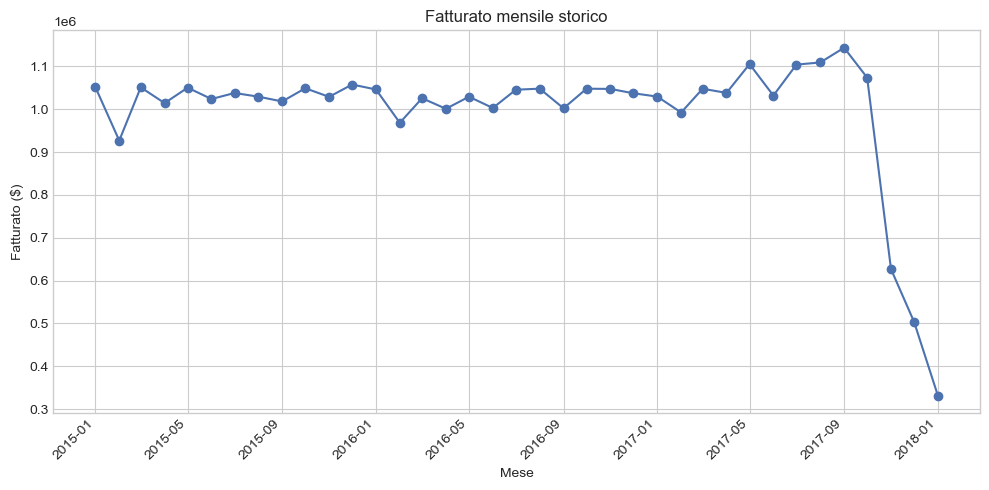

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df["mese"], df["fatturato_totale"], marker="o", color="#4C72B0")
plt.title("Fatturato mensile storico")
plt.xlabel("Mese")
plt.ylabel("Fatturato ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("images/fatturato_storico.png", dpi=150)
plt.show()

## 3. Forecasting con media mobile (baseline)

Approccio semplice: prevediamo il prossimo mese come media degli ultimi 3 mesi. Utile come punto di riferimento per valutare se un modello piu' complesso (Prophet) porta un miglioramento reale.

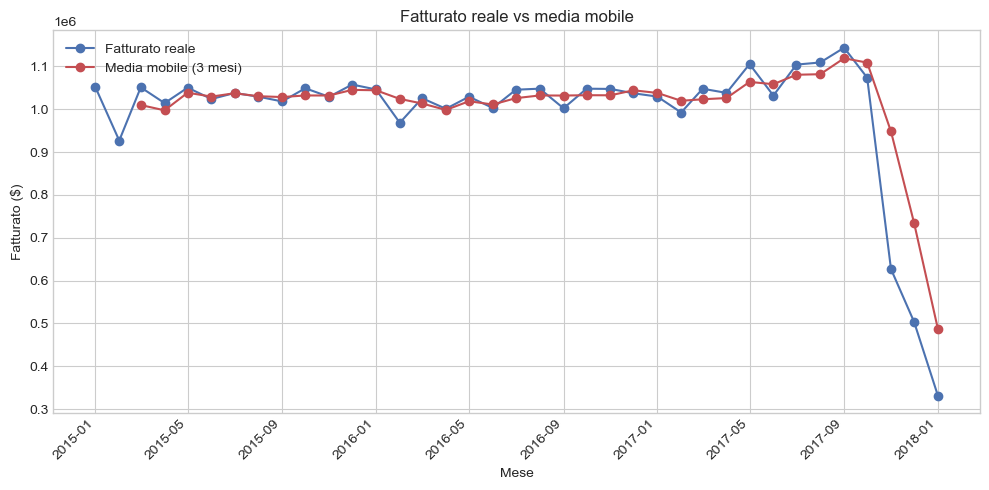

In [7]:
WINDOW = 3

df_ma = df.copy()
df_ma["media_mobile"] = df_ma["fatturato_totale"].rolling(window=WINDOW).mean()

plt.figure(figsize=(10, 5))
plt.plot(df_ma["mese"], df_ma["fatturato_totale"], marker="o", label="Fatturato reale", color="#4C72B0")
plt.plot(df_ma["mese"], df_ma["media_mobile"], marker="o", label=f"Media mobile ({WINDOW} mesi)", color="#C44E52")
plt.title("Fatturato reale vs media mobile")
plt.xlabel("Mese")
plt.ylabel("Fatturato ($)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("images/media_mobile.png", dpi=150)
plt.show()

## 4. Forecasting con Prophet

Prophet richiede le colonne rinominate in `ds` (data) e `y` (valore da prevedere). Prevediamo i prossimi 3 mesi oltre l'ultimo dato disponibile.

In [8]:
df_prophet = df.rename(columns={"mese": "ds", "fatturato_totale": "y"})

model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods=3, freq="MS")  # MS = inizio mese
forecast = model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(6)

11:11:51 - cmdstanpy - INFO - Chain [1] start processing
11:11:52 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
34,2017-11-01,842821.838064,676198.648805,9.970868e+05
35,2017-12-01,802584.142531,645186.592342,9.765848e+05
36,2018-01-01,759104.953192,592234.026897,9.289966e+05
37,2018-02-01,871013.705773,708918.227088,1.030164e+06
38,2018-03-01,920803.170481,751882.645319,1.089258e+06
39,2018-04-01,900248.751568,721780.717255,1.058781e+06


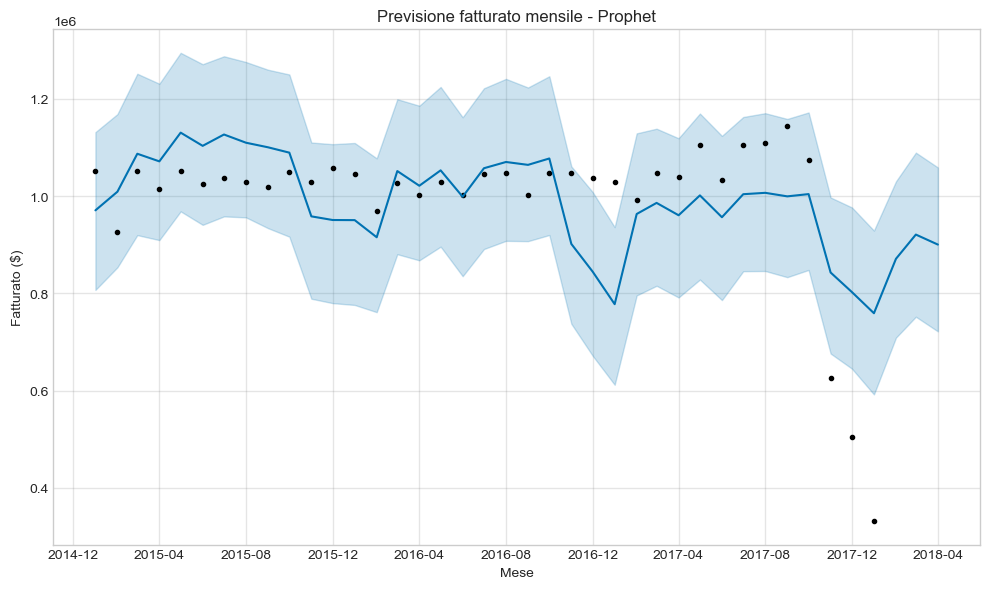

In [9]:
fig = model.plot(forecast)
plt.title("Previsione fatturato mensile - Prophet")
plt.xlabel("Mese")
plt.ylabel("Fatturato ($)")
plt.tight_layout()
plt.savefig("images/prophet_forecast.png", dpi=150)
plt.show()

## 5. Componenti del modello

Prophet scompone la previsione in trend e stagionalita' - utile per capire *perche'* il modello prevede quello che prevede, non solo il numero finale.

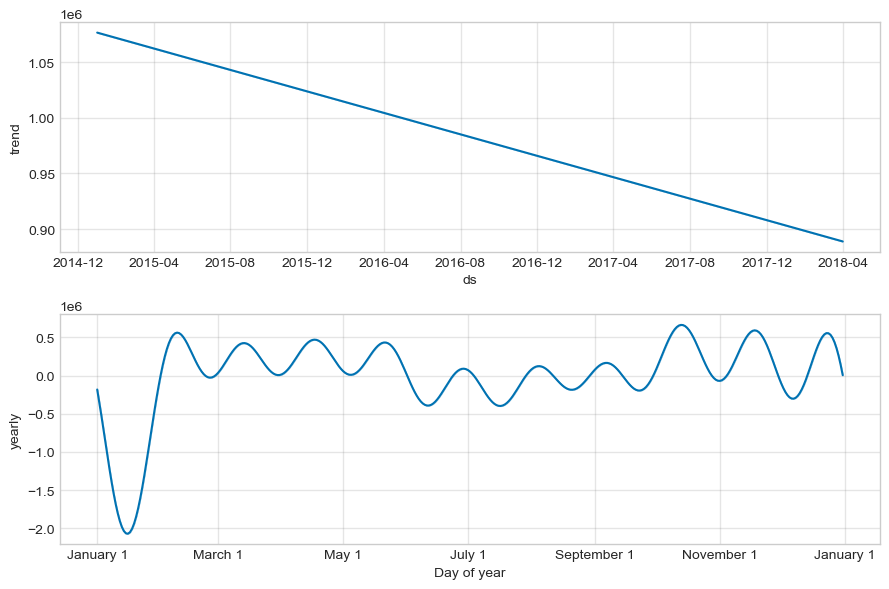

In [10]:
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.savefig("images/prophet_components.png", dpi=150)
plt.show()

In [12]:
query_check = """
    SELECT DATE_FORMAT(STR_TO_DATE(order_date_dateorders, '%c/%e/%Y %H:%i'), '%Y-%m') AS mese,
           COUNT(*) AS numero_ordini
    FROM orders
    GROUP BY DATE_FORMAT(STR_TO_DATE(order_date_dateorders, '%c/%e/%Y %H:%i'), '%Y-%m')
    ORDER BY mese
    LIMIT 5;
"""
pd.read_sql_query(query_check, engine)

,mese,numero_ordini
0,2015-01,5322
1,2015-02,4729
2,2015-03,5362
3,2015-04,5126
4,2015-05,5357


## 6. Conclusioni

- Il fatturato mostra un trend in calo costante nel periodo osservato, passando da circa 1,08 milioni di dollari (fine 2014) a circa 0,89 milioni di dollari (inizio 2018)
- La stagionalita' annuale mostra un calo marcato a inizio gennaio e picchi ricorrenti tra fine ottobre e inizio novembre. Verificando il numero di ordini per mese, gennaio non presenta un volume di ordini inferiore agli altri mesi (circa 5.300 ordini, in linea con febbraio-maggio) - quindi il calo sembra un pattern stagionale reale (es. rallentamento post-festivita'), non un artefatto di dati incompleti
- La previsione per i prossimi 3 mesi (febbraio-aprile 2018) indica un fatturato stabile, attorno a 900.000 dollari al mese, con un intervallo di incertezza che si allarga progressivamente man mano che ci si allontana dai dati osservati
- Rispetto alla media mobile semplice, Prophet cattura meglio i pattern stagionali reali (es. il calo di gennaio e i picchi di fine ottobre), che la media mobile tende a smussare o ignorare completamente